In [10]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
#os.environ['XLA_FLAGS'] = '--xla_gpu_autotune_level=0'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [11]:
import keras
import numpy as np
import torchvision

# MNIST dataset
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                           train=True,
                                           transform=transform,
                                           download=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data',
                                          train=False,
                                          transform=transform)

X_train = train_dataset.data
y_train = np.array(train_dataset.targets)

X_test = test_dataset.data
y_test = np.array(test_dataset.targets)

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f"Размер тренировочных данных: {X_train.shape}")
print(f"Размер тестовых данных: {X_test.shape}")
print(f"Метки классов: {np.unique(y_train)}")


Размер тренировочных данных: (50000, 32, 32, 3)
Размер тестовых данных: (10000, 32, 32, 3)
Метки классов: [0 1 2 3 4 5 6 7 8 9]


In [12]:
from matplotlib import pyplot as plt

def train_and_evaluate_model(model, epochs=10, batch_size=32):
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"\nТестовая точность: {test_accuracy:.4f}")
    print(f"Тестовая потеря: {test_loss:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].set_title('Точность модели')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Точность')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].set_title('Потери модели')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Потери')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return model


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1292 - loss: 41.1992 
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 946us/step - accuracy: 0.1001 - loss: 2.3031
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step - accuracy: 0.0975 - loss: 2.3019
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 933us/step - accuracy: 0.0986 - loss: 2.3026
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 923us/step - accuracy: 0.0967 - loss: 2.3029
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 913us/step - accuracy: 0.0982 - loss: 2.3033
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 931us/step - accuracy: 0.0996 - loss: 2.3027
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step - accuracy: 0.0969 - loss: 2.3048
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step - accuracy: 0.0991 - loss: 2.3285
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 926us/step - accuracy: 0.0979 - loss: 2.3028

Тестовая точность: 0.0998
Тестовая потеря: 2.3045


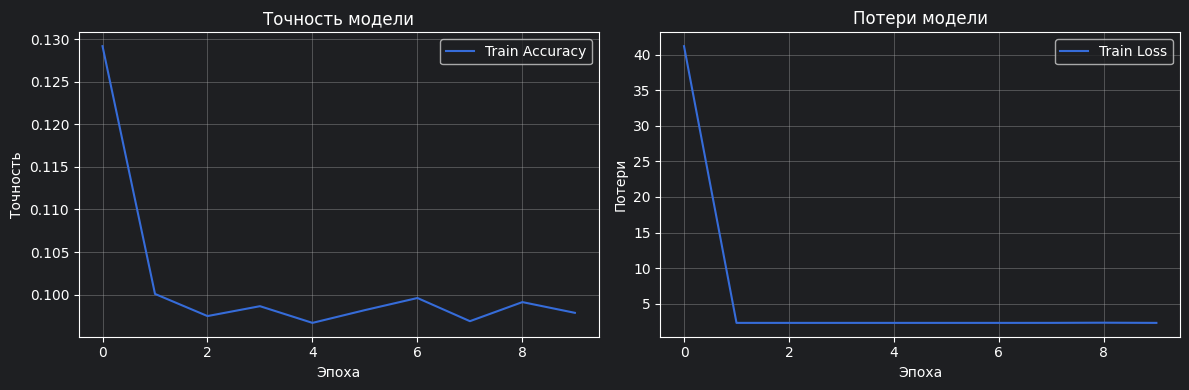

In [13]:
# TASK 1: baseline model but in tensorflow

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(1000, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model());

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0993 - loss: 15.8044
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 960us/step - accuracy: 0.0967 - loss: 2.3028
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step - accuracy: 0.0973 - loss: 2.3028
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 974us/step - accuracy: 0.0981 - loss: 2.3028
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 973us/step - accuracy: 0.0984 - loss: 2.3028
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 953us/step - accuracy: 0.0962 - loss: 2.3028
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 955us/step - accuracy: 0.0960 - loss: 2.3028
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 962us/step - accuracy: 0.0998 - loss: 2.3028
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 966us/step - accuracy: 0.0961 - loss: 2.3028
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 991us/step - accuracy: 0.0976 - loss: 2.3028

Тестовая точность: 0.1000
Тестовая потеря: 2.3026


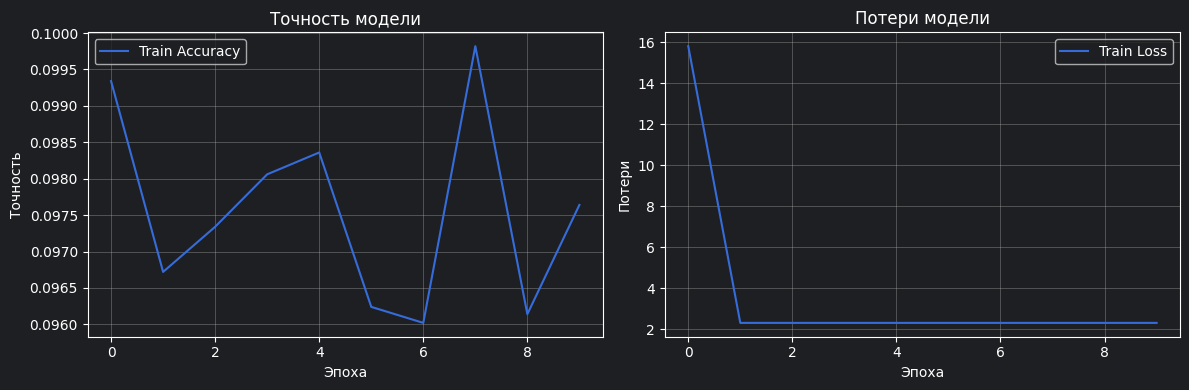

In [14]:
# TASK 2: additional dense layer

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(1000, activation='relu')(x)
    x = layers.Dense(100, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model());

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.0985 - loss: 6.2931 
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0971 - loss: 3.8748
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1003 - loss: 2.3027
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0975 - loss: 2.3028
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0991 - loss: 2.3028
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0983 - loss: 2.3028
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0993 - loss: 2.3028
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0990 - loss: 2.3028
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1002 - loss: 2.3027
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0979 - loss: 2.3028

Тестовая точность: 0.1000
Тестовая потеря: 2.3027


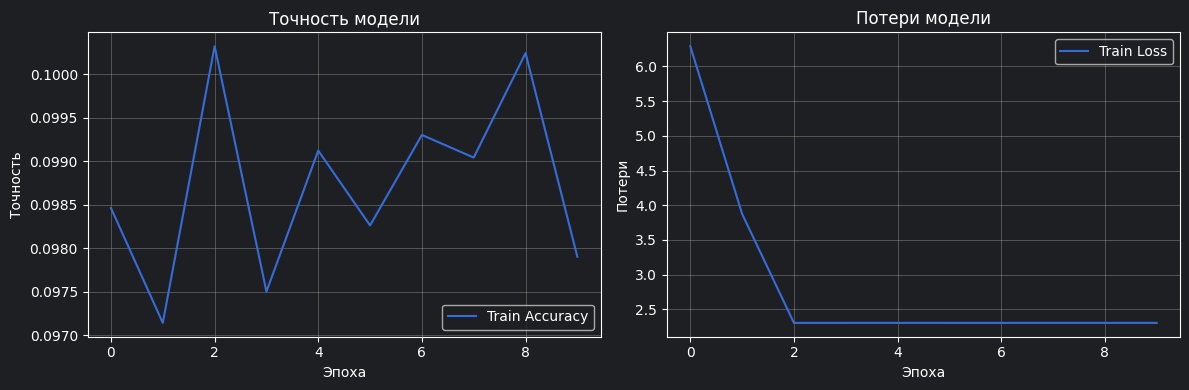

In [15]:
# TASK 3: more additional dense layers

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model());

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.1052 - loss: 4.7210 
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0988 - loss: 2.3228
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0983 - loss: 2.3028
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0964 - loss: 2.3028
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0985 - loss: 2.3028
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0968 - loss: 2.3028
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0982 - loss: 2.3028
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0977 - loss: 2.3028
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0980 - loss: 2.3027
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0986 - loss: 2.3027

Тестовая точность: 0.1000
Тестовая потеря: 2.3027


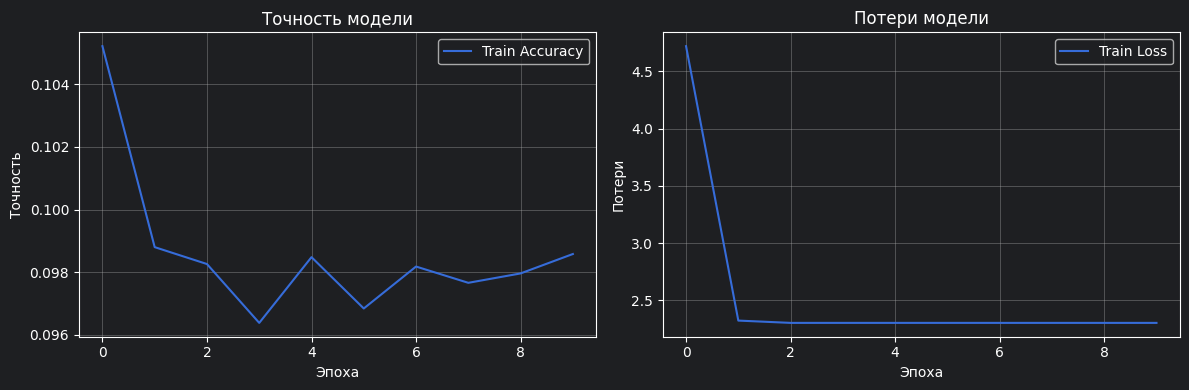

In [16]:
# TASK 4: dropouts

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model());

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.3800 - loss: 1.7265
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4590 - loss: 1.5171
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4967 - loss: 1.4185
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5263 - loss: 1.3321
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5532 - loss: 1.2636
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5780 - loss: 1.1950
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5943 - loss: 1.1395
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6166 - loss: 1.0763
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6358 - loss: 1.0229
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6581 - loss: 0.9632

Тестовая точность: 0.5627
Тестовая потеря: 1.3065


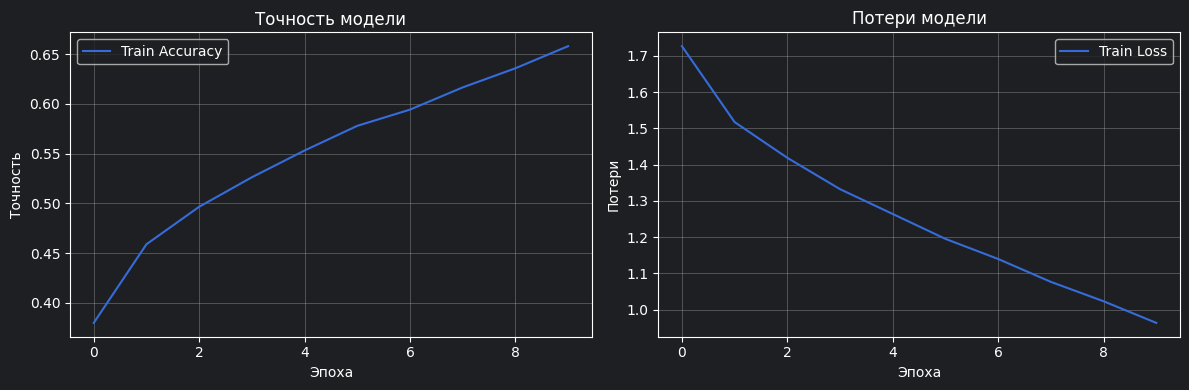

In [17]:
# TASK 5: batch normalization instead of dropouts

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model());

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step


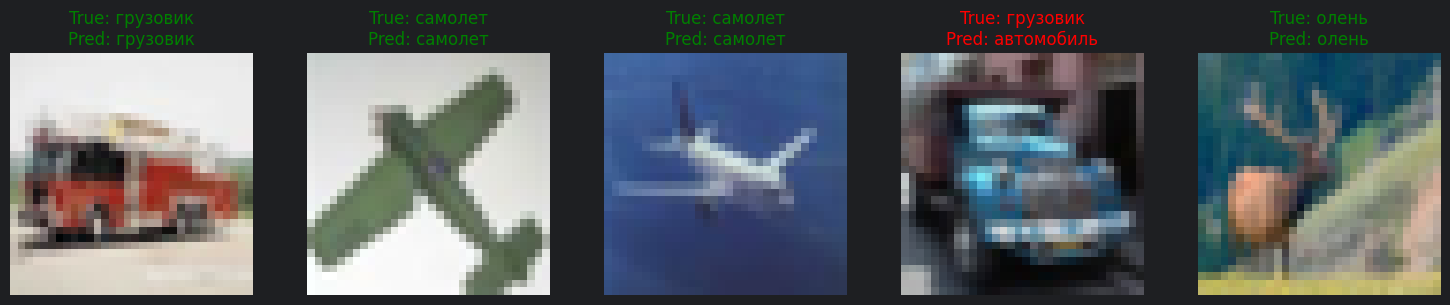

In [18]:
class_names = ['самолет', 'автомобиль', 'птица', 'кот', 'олень',
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

# Функция для визуализации предсказаний
def show_predictions(model, x_test, y_test, num_images=5):
    indices = np.random.choice(len(x_test), num_images, replace=False)

    predictions = model.predict(x_test[indices])
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = y_test[indices]

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for i, idx in enumerate(indices):
        axes[i].imshow(x_test[idx])
        axes[i].axis('off')

        color = 'green' if predicted_classes[i] == true_classes[i] else 'red'
        title = f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}"
        axes[i].set_title(title, color=color)

    plt.tight_layout()
    plt.show()

show_predictions(model, X_test, y_test)